# Module 1 Part-A: Premium Prediction (Regression)

# Import Libraries

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


# Load Dataset

In [7]:
# Load the Excel dataset

df = pd.read_excel(
    "../data/Premium/Insurance_Premium_Dataset.xlsx",
    sheet_name="Data"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# data understanding 

In [4]:
df.head()

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_inr,exercise_frequency,alcohol_consumption,medical_history,family_medical_history,annual_premium_inr
0,CUST100001,22,male,27.7,4,yes,west,business_owner,446000.0,3-4_per_week,regular,diabetes,no,39650
1,CUST100002,59,female,23.1,5,no,east,retired,261000.0,1-2_per_week,occasional,diabetes,no,27690
2,CUST100003,52,female,29.9,2,no,south,salaried,174000.0,1-2_per_week,occasional,none,no,16970
3,CUST100004,41,female,28.4,2,no,east,salaried,769000.0,1-2_per_week,none,none,no,11330
4,CUST100005,40,male,26.4,1,no,south,salaried,142000.0,none,regular,none,yes,21630


In [4]:
df.shape

(50060, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50060 entries, 0 to 50059
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             50060 non-null  object 
 1   age                     50060 non-null  int64  
 2   gender                  50060 non-null  object 
 3   bmi                     49510 non-null  float64
 4   children                50060 non-null  int64  
 5   smoker                  50060 non-null  object 
 6   region                  50060 non-null  object 
 7   occupation              50060 non-null  object 
 8   annual_income_inr       49010 non-null  float64
 9   exercise_frequency      50060 non-null  object 
 10  alcohol_consumption     50060 non-null  object 
 11  medical_history         50060 non-null  object 
 12  family_medical_history  50060 non-null  object 
 13  annual_premium_inr      50060 non-null  int64  
dtypes: float64(2), int64(3), object(9)
mem

In [6]:
df.isnull().sum()

customer_id                  0
age                          0
gender                       0
bmi                        550
children                     0
smoker                       0
region                       0
occupation                   0
annual_income_inr         1050
exercise_frequency           0
alcohol_consumption          0
medical_history              0
family_medical_history       0
annual_premium_inr           0
dtype: int64

# handling missing values 

In [7]:
# Fill missing values with median

df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df["annual_income_inr"] = df["annual_income_inr"].fillna(df["annual_income_inr"].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [8]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
bmi                       0
children                  0
smoker                    0
region                    0
occupation                0
annual_income_inr         0
exercise_frequency        0
alcohol_consumption       0
medical_history           0
family_medical_history    0
annual_premium_inr        0
dtype: int64

In [9]:
df.describe()

,age,bmi,children,annual_income_inr,annual_premium_inr
count,50060.000000,50060.000000,50060.000000,5.006000e+04,50060.000000
mean,43.970336,27.472984,1.514742,6.266844e+05,24521.981822
std,15.309619,5.143803,1.336314,3.706867e+05,9999.973365
min,18.000000,15.500000,0.000000,4.500000e+04,5000.000000
25%,31.000000,24.000000,0.000000,3.760000e+05,17290.000000
50%,44.000000,27.400000,1.000000,5.390000e+05,22690.000000
75%,57.000000,30.900000,2.000000,7.770000e+05,30050.000000
max,70.000000,50.900000,5.000000,5.062000e+06,68810.000000


# Exploratory data analysis(EDA)

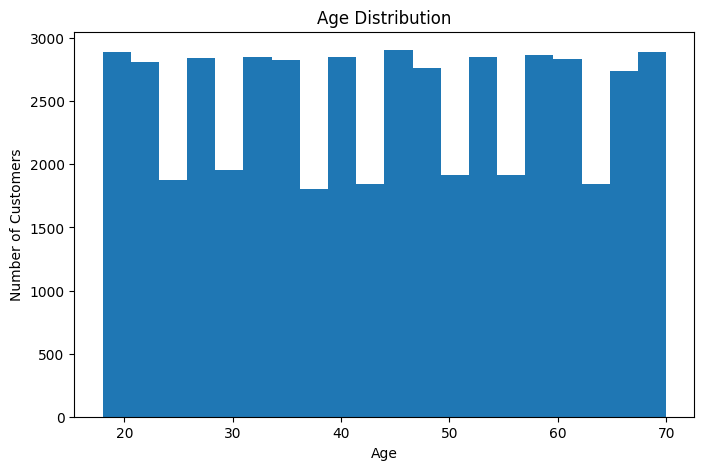

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

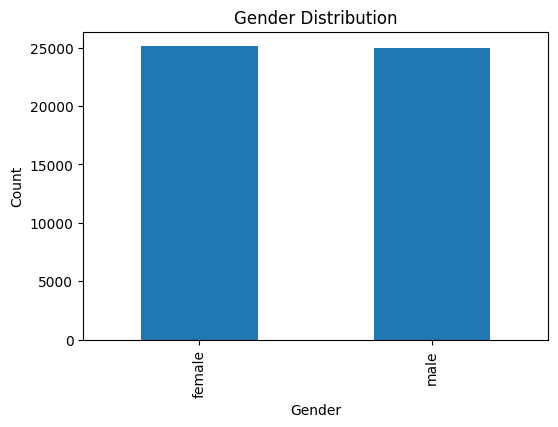

In [11]:
plt.figure(figsize=(6,4))

df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

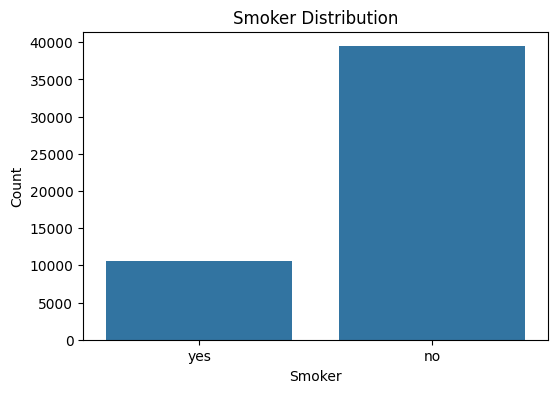

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df)
plt.title("Smoker Distribution")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

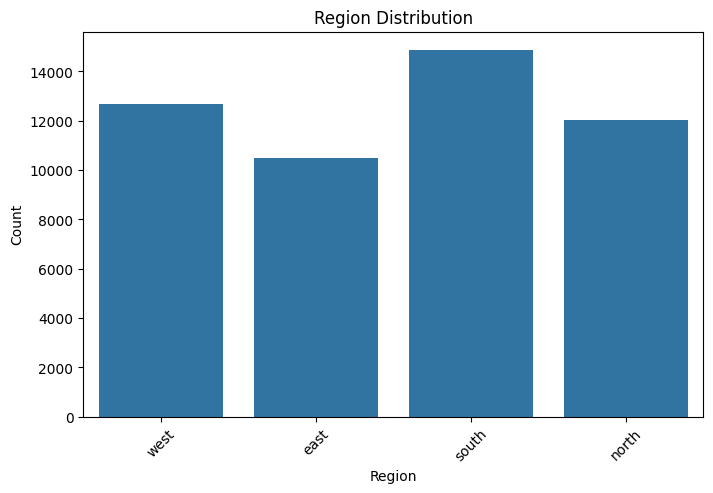

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='region', data=df)
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

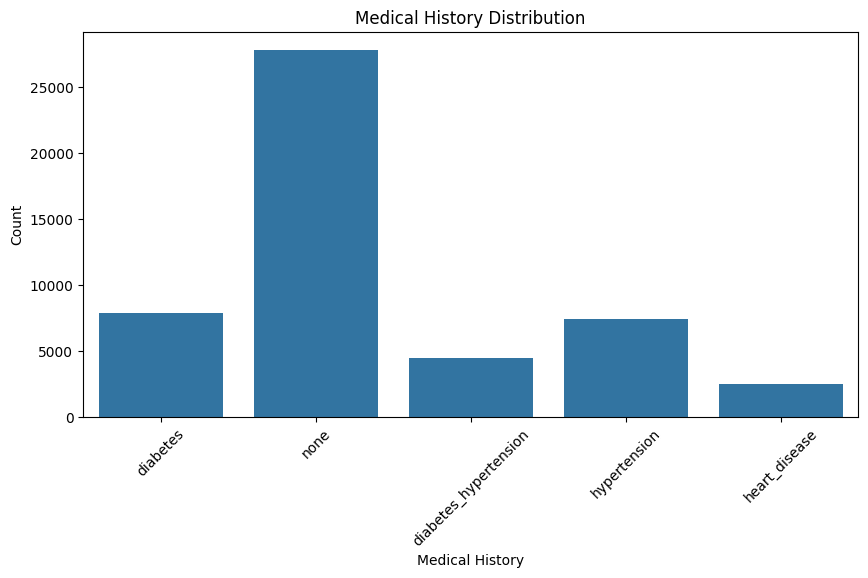

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='medical_history', data=df)
plt.title("Medical History Distribution")
plt.xlabel("Medical History")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

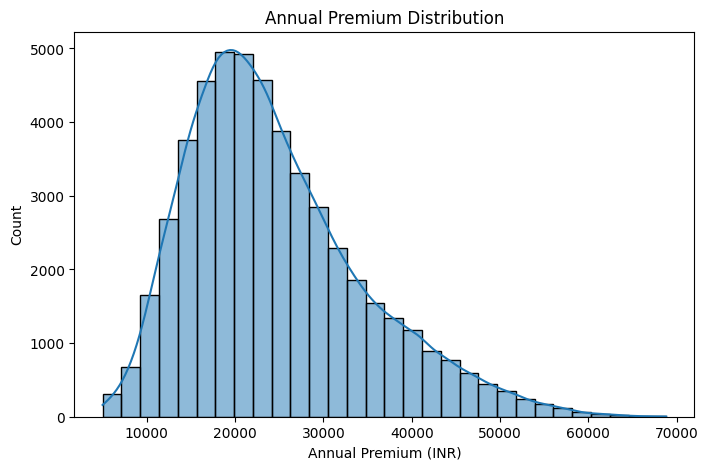

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['annual_premium_inr'], bins=30, kde=True)
plt.title("Annual Premium Distribution")
plt.xlabel("Annual Premium (INR)")
plt.ylabel("Count")
plt.show()

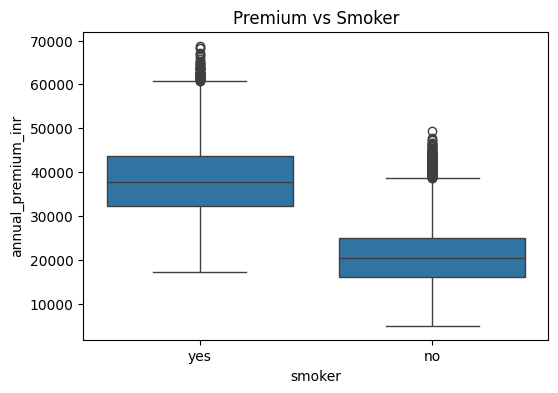

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="annual_premium_inr", data=df)
plt.title("Premium vs Smoker")
plt.show()

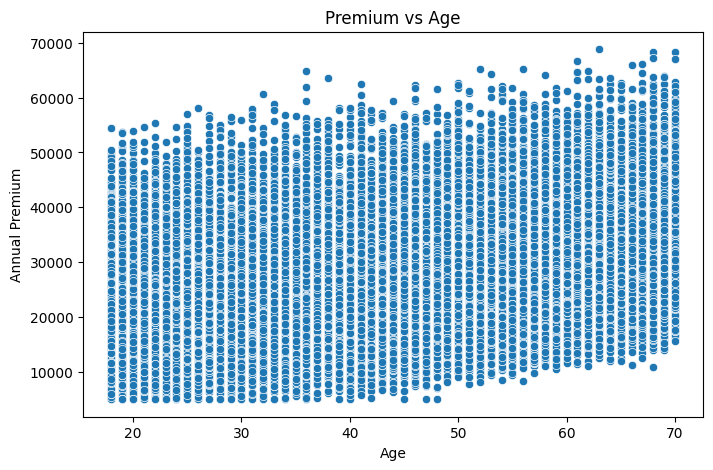

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="annual_premium_inr", data=df)
plt.title("Premium vs Age")
plt.xlabel("Age")
plt.ylabel("Annual Premium")
plt.show()

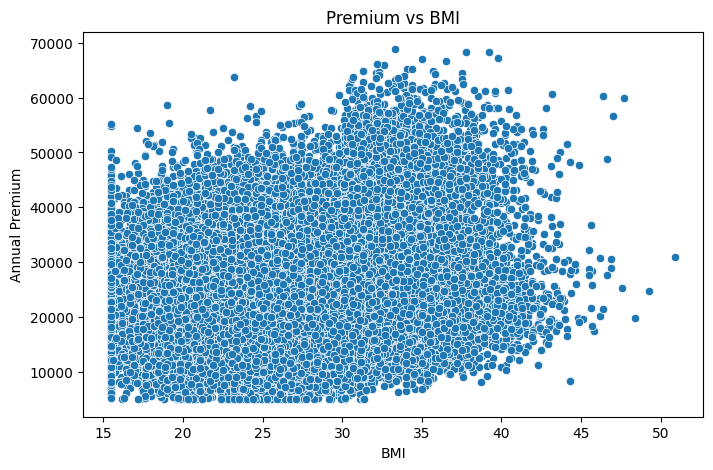

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="annual_premium_inr", data=df)
plt.title("Premium vs BMI")
plt.xlabel("BMI")
plt.ylabel("Annual Premium")
plt.show()

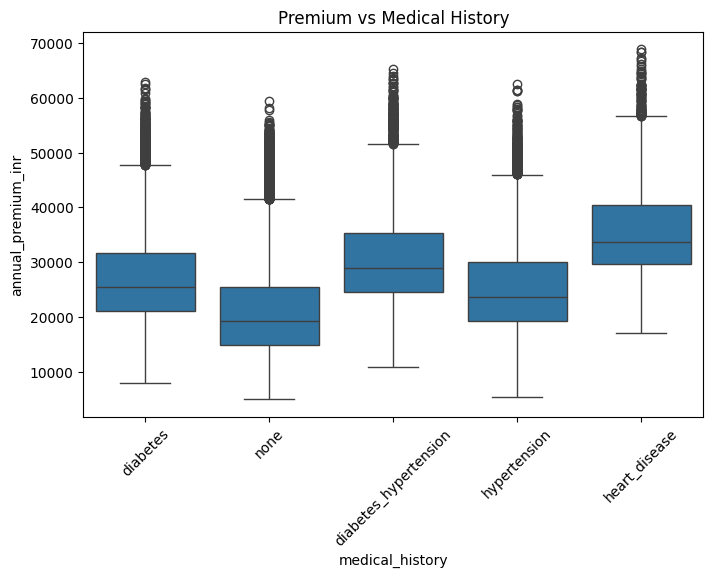

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="medical_history", y="annual_premium_inr", data=df)
plt.title("Premium vs Medical History")
plt.xticks(rotation=45)
plt.show()

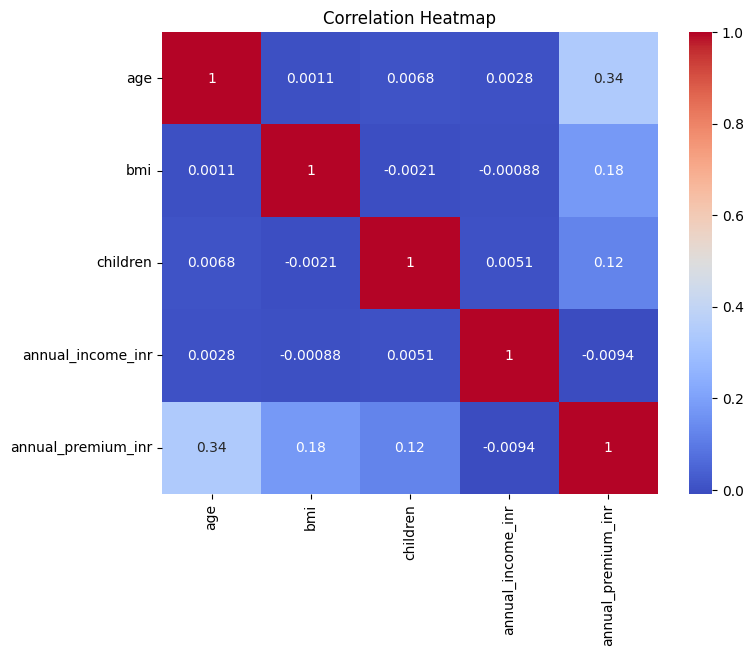

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Feature selection 

In [26]:
df.select_dtypes(include='object').columns

Index(['gender', 'smoker', 'region', 'occupation', 'exercise_frequency',
       'alcohol_consumption', 'medical_history', 'family_medical_history'],
      dtype='object')

In [10]:
# Recreate Features and Target after dropping customer_id

X = df.drop("annual_premium_inr", axis=1)
y = df["annual_premium_inr"]

print(X.columns)

Index(['customer_id', 'age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'occupation', 'annual_income_inr', 'exercise_frequency',
       'alcohol_consumption', 'medical_history', 'family_medical_history'],
      dtype='object')


In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'occupation', 'annual_income_inr', 'exercise_frequency',
       'alcohol_consumption', 'medical_history', 'family_medical_history',
       'annual_premium_inr'],
      dtype='object')

In [12]:
# Remove customer_id permanently
df = df.drop(columns=["customer_id"])

# Verify that it is removed
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'occupation',
       'annual_income_inr', 'exercise_frequency', 'alcohol_consumption',
       'medical_history', 'family_medical_history', 'annual_premium_inr'],
      dtype='object')

# Feature and Target 

In [20]:


X = df.drop("annual_premium_inr", axis=1)
y = df["annual_premium_inr"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50060, 12)
Target Shape: (50060,)


# Train Test Split 

In [21]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (40048, 12)
X_test Shape: (10012, 12)
y_train Shape: (40048,)
y_test Shape: (10012,)


 # Encode Categorical Feature 

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical columns
categorical_features = [
    'gender',
    'smoker',
    'region',
    'occupation',
    'exercise_frequency',
    'alcohol_consumption',
    'medical_history',
    'family_medical_history'
]

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Fit on training data only
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data
X_test_encoded = preprocessor.transform(X_test)

print("Encoding completed successfully!")
print("Encoded X_train Shape:", X_train_encoded.shape)
print("Encoded X_test Shape:", X_test_encoded.shape)

Encoding completed successfully!
Encoded X_train Shape: (40048, 31)
Encoded X_test Shape: (10012, 31)


# Feature Scaling 

In [24]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler(with_mean=False)

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform test data
X_test_scaled = scaler.transform(X_test_encoded)

print("Feature Scaling completed successfully!")
print("Scaled X_train Shape:", X_train_scaled.shape)
print("Scaled X_test Shape:", X_test_scaled.shape)

Feature Scaling completed successfully!
Scaled X_train Shape: (40048, 31)
Scaled X_test Shape: (10012, 31)


# Model Training 
## Linear Regression  Model 

In [25]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [26]:
# Predict on the test data
y_pred_lr = lr_model.predict(X_test_scaled)

print("Prediction completed successfully!")

Prediction completed successfully!


In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Evaluation metrics
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Performance")
print("R² Score :", lr_r2)
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)

Linear Regression Performance
R² Score : 0.898167545628936
MAE : 2516.584518227297
RMSE : 3200.351167588848


## Random Forest  Model 

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [29]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Prediction completed successfully!")

Prediction completed successfully!


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print("R² Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Performance
R² Score: 0.9176620249727336
MAE: 2293.072003595685
RMSE: 2877.7603230558752


## Gradiendt Boosting Model 

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
gb_model.fit(X_train_scaled, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [32]:
# Predict on test data
y_pred_gb = gb_model.predict(X_test_scaled)

print("Prediction completed successfully!")

Prediction completed successfully!


In [33]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting Performance")
print("R² Score:", gb_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)

Gradient Boosting Performance
R² Score: 0.9268561009539458
MAE: 2163.5024043827807
RMSE: 2712.3365926744464


# Model Comparision 

In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.898168,2516.584518,3200.351168
1,Random Forest Regressor,0.917662,2293.072004,2877.760323
2,Gradient Boosting Regressor,0.926856,2163.502404,2712.336593


# Save Best Model 

In [35]:
import joblib

# Save the best model
joblib.dump(gb_model, "gradient_boosting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Preprocessor and Scaler saved successfully!")

Preprocessor and Scaler saved successfully!


In [2]:
import joblib

# Load the model
model = joblib.load("../models/gradient_boosting_model.pkl")

print("✅ Model Loaded Successfully!")
print(model)

✅ Model Loaded Successfully!
GradientBoostingRegressor(random_state=42)
